In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

from utils.helper_functions import load_data, assign_fixed_rewards, sample_reward_offset
from utils.world import VillageWorld
from utils.plot_functions import plot_world, plot_paths, plot_figure1, plot_individual_tiles 

In [2]:
# Set random seed for reproducibility
rng = np.random.default_rng(5)

In [ ]:
# LOAD WORLDS
worlds_load = np.load('saved/worlds.npz')
worlds_saved = [worlds_load[f'arr_{i}'] for i in range(len(worlds_load.files))]
#worlds_saved

# LOAD REWARDS_INFO FOR BASELINE
rewards_info_load = np.load('saved/rewards_info.npz')
rewards_info = [rewards_info_load[f'arr_{i}'] for i in range(len(rewards_info_load.files))]

# LOAD REWARDS_INFO FOR EXP2
rewards_info_load_exp2 = np.load('saved/rewards_exp2.npz')
rewards_info_exp2 = [rewards_info_load_exp2[f'arr_{i}'] for i in range(len(rewards_info_load_exp2.files))]

# LOAD TRUE TRANSITION MATRICES
true_tms_load = np.load('saved/true_tms.npz')
true_tms = [true_tms_load[f'arr_{i}'] for i in range(len(true_tms_load.files))]

# LOAD TRUE TRANSITION MATRIX (DOES NOT CONSIDER WALLS)
init_tms_load = np.load('saved/init_tms.npz')
init_tms = [init_tms_load[f'arr_{i}'] for i in range(len(init_tms_load.files))]

#### Visualize Worlds

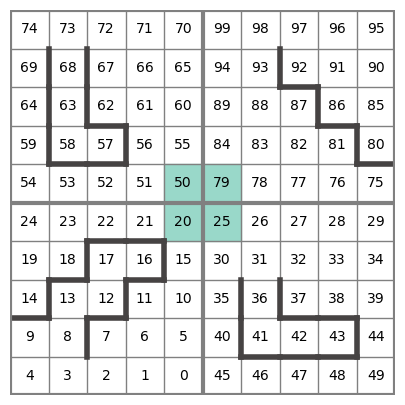

In [ ]:
## Visualize the world of a specific simulation and episode with reward information

# Select the world and episode to plot
exp = 'exp3'  
sim = 6 
epi = 0

# Load the world
world = worlds_saved[sim]
env = VillageWorld(world)

# Boundaries of the world
boundaries = env.get_all_boundaries()

# Reward locations
rewards_info_sim = rewards_info[sim][epi]
reward_states = env.reward_states

# Plot the world
plot_world(env, world, rewards_info_sim, state_num = True, reward_text = False, reward_color = True, dashed_squares = None, boundaries = boundaries, savefigpath = False)

# Save figure to saved folder (if folder doesn't exists, create it)
save_dir = os.path.join('saved', 'Figures', 'world')
os.makedirs(save_dir, exist_ok=True)
#save_path = os.path.join(save_dir, f'world_{exp}.png')
#plt.savefig(save_path, bbox_inches='tight', pad_inches=0)
#plt.title(title)

plt.show()

c:\Users\kessl\OneDrive - UT Cloud\Dokumente\Uni\Master\Laborpraktikum_2\RL_social\utils\plot_functions.py:63: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-" (-> color='k'). The keyword argument will take precedence.
  ax.plot([converted_lines[0][1], converted_lines[0][1]+1] , [grid_size-y_max, grid_size-y_max], 'k-', linewidth=4, color="#464343ff")
c:\Users\kessl\OneDrive - UT Cloud\Dokumente\Uni\Master\Laborpraktikum_2\RL_social\utils\plot_functions.py:57: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-" (-> color='k'). The keyword argument will take precedence.
  ax.plot([x_max, x_max], y_axis, 'k-', linewidth=4, color="#464343ff")


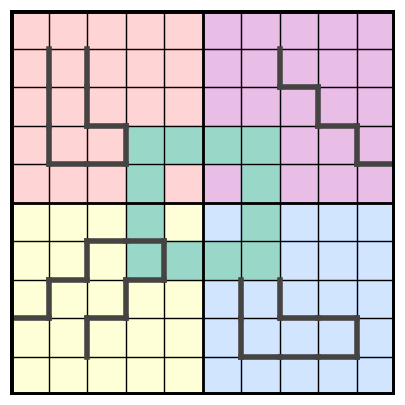

In [ ]:
## Visualize the world of a specific simulation and episode with reward information in the style of Figure 1 in the paper

# Select the world and episode to plot
exp = 'exp3'  
sim = 6 
epi = 0

# Load the world
world = worlds_saved[sim]
env = VillageWorld(world)

# Boundaries of the world
boundaries = env.get_all_boundaries()

# Reward locations
rewards_info_sim = rewards_info[sim][epi]
reward_states = env.reward_states

# Plot the world
plot_figure1(env, world, rewards_info_sim, state_num = False, reward_text = False, reward_color = True, dashed_squares = None, boundaries = boundaries, exp = exp, savefigpath = False)

# Save figure to saved folder (if folder doesn't exists, create it)
save_dir = os.path.join('saved', 'Figures', 'world')
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, f'world_{exp}.png')
#plt.savefig(save_path, bbox_inches='tight', pad_inches=0)
plt.show()

In [ ]:
## Plot individual tiles of the world with reward information in the style of Figure 1 in the paper
plot_individual_tiles(env, world, reward_info = rewards_info_sim, state_num = False, reward_text = False, reward_color = True, dashed_squares = None, boundaries = boundaries)

##### Generalization 1: Block original pathway to reward states (Deprecated)

In [ ]:
mode = 'gen1'
sim = 3
epi = 0
epi_expert = epi + 100

# Load the world
world = worlds_saved[sim]
env = VillageWorld(world)

# Boundaries of the world
boundaries = env.get_boundaries_gen1()

# Reward locations
rewards_info_sim = rewards_info[sim][epi]
reward_states = env.reward_states

# Plot the world
#title = f"New gen1 world"
plot_world(env, world, rewards_info_sim, state_num = False, reward_text = True, reward_color = True, dashed_squares = None, boundaries = boundaries, transition_matrix = None,  savefigpath = False)

# Save figure to saved folder (if folder doesn't exists, create it)
save_dir = os.path.join('saved', 'figures')
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, f'world_{mode}.pdf')
#plt.savefig(save_path, bbox_inches='tight')
#plt.title(title)


plt.show()

#### Generate Worlds

In [ ]:
# TO SAVE THE WORLDS 
n_simulations = 1000
worlds = []

for s in range(n_simulations):
    env = VillageWorld(rng=rng)
    worlds.append(env.get_world_matrix())

# Save the worlds
np.savez_compressed('saved/worlds.npz', *worlds)

In [ ]:
# LOAD WORLDS
worlds_load = np.load('saved/worlds.npz')
worlds_saved = [worlds_load[f'arr_{i}'] for i in range(len(worlds_load.files))]
worlds_saved

#### Generate Rewards

##### Fixed Rewards

In [ ]:
# For each simulation we randomly assign fixed reward values to each reward state
n_simulations = 1000
n_episodes = 120
## TO SAVE THE REWARDS 
save_rewards_info = []
for s in range(n_simulations):
    env = VillageWorld(worlds_saved[s], rng=rng)
    # Assign a fixed reward value to each reward state
    reward_values = assign_fixed_rewards(env, rng)
    rewards_episode = [reward_values.copy() for _ in range(n_episodes)]
    save_rewards_info.append(rewards_episode)
# Save the worlds
np.savez_compressed('saved/rewards_fixed.npz', *save_rewards_info)

In [5]:
# LOAD REWARDS_INFO
rewards_fixed_load = np.load('saved/rewards_fixed.npz')
rewards_fixed = [rewards_fixed_load[f'arr_{i}'] for i in range(len(rewards_info_load.files))]

In [ ]:
# How rewards are introduced to the social agents
sim = 0
n_episodes = 20
episode = 0
rewards_info[sim][-n_episodes:, :].shape
rewards_info[sim][-n_episodes:, :][episode][:,:2].shape

##### Add Stochasticity

In [ ]:
# Finding fitting variance for noise to be added to rewards
# - should lead to occasional crossovers between rewards
# - should avoid negative rewards

# Sample offsets for 1000 sim * 20 episodes * 3 rewards
n_simulations = 1000
n_episodes = 20
target_variance = 100 # 120 for ~ 10% crossovers

rewards = np.array([25, 50, 75])

# Shuffle rewards each simulation 
all_rewards = []
for sim in range(n_simulations):
    shuffled = np.random.permutation(rewards)
    all_rewards.extend([shuffled.copy() for _ in range(n_episodes)])
all_rewards = np.array(all_rewards)

# Sample offsets
offsets = np.array([sample_reward_offset(target_variance) for _ in range(n_simulations * n_episodes * len(rewards))])

# Print min and max offsets
print(f"Min offset: {min(offsets)}, Max offset: {max(offsets)}")

# Count crossovers
crossover_count = 0
negative_count = 0

for i in range(n_simulations * n_episodes):
    sampled_offsets = offsets[3*i : 3*i + 3]
    noisy_rewards = all_rewards[i] + sampled_offsets
    
    # Check if the order has changed
    if not np.all(np.argsort(noisy_rewards) == np.argsort(all_rewards[i])):
        crossover_count += 1
    # Check if any reward is negative
    if np.any(noisy_rewards < 0):
        negative_count += 1

# Empirical probability
p_crossover = crossover_count / (n_simulations * n_episodes)
print(f"Empirical probability of a crossover: {p_crossover:.4f}")

p_negative = negative_count / (n_simulations * n_episodes)
print(f"Empirical probability that a reward becomes negative: {p_negative:.4f}")

# Compute standard deviation
sigma = np.sqrt(target_variance)
lower_2sigma = -2 * sigma
upper_2sigma = 2 * sigma
print(f"±2σ interval: [{lower_2sigma}, {upper_2sigma}]")

# Plot histogram of offsets
bins = np.arange(min(offsets) - 0.5, max(offsets) + 1.5, 1)
plt.hist(offsets, bins=bins, density=True, edgecolor='black')
plt.title(f'Histogram of added noise to rewards (Var={target_variance})')
plt.xlabel('Added noise')
plt.ylabel('Density')
# Add ±2σ bracket
y_min, y_max = plt.ylim()  
y_pos = y_min + 0.5*(y_max - y_min) 
plt.hlines(y=y_pos, xmin=lower_2sigma, xmax=upper_2sigma, color='black', linewidth=1)
plt.vlines([lower_2sigma, upper_2sigma], y_pos - 0.01*(y_max - y_min), y_pos + 0.01*(y_max - y_min), color='black', linewidth=1)
plt.text(0, y_pos + 0.01*(y_max - y_min), '±2σ', color='black', ha='center')
# Add probabilities in the upper-right corner
text_str = f"Crossover: ~ {p_crossover:.2%}\nNegative rewards: ~ {p_negative:.2%}"
plt.text(0.98, 0.92, text_str, transform=plt.gca().transAxes,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
plt.grid(True)
plt.show()



In [ ]:
# LOAD FIXED REWARDS
rewards_fixed_load = np.load('saved/rewards_fixed.npz')
rewards_fixed = [rewards_fixed_load[f'arr_{i}'] for i in range(len(rewards_fixed_load.files))]

In [ ]:
# Rewards with noise
n_simulations = 1000
n_episodes = 120
target_var = 100
n_rewards = rewards_fixed[0][0].shape[0]

# Sample offsets
offsets = np.array([sample_reward_offset(target_var) 
                    for _ in range(n_simulations * n_episodes * n_rewards)])


## TO SAVE THE REWARDS 
save_rewards_info_noise = []
for sim in range(n_simulations):
    sim_rewards_noisy = []
    for episode in range(n_episodes):
        episode_rewards = rewards_fixed[sim][episode].copy()
        # Add noise to non-zero rewards
        for idx in range(episode_rewards.shape[0]):
            if episode_rewards[idx, 1] != 0:
                episode_rewards[idx, 1] += offsets[sim * n_episodes * n_rewards + episode * n_rewards + idx]
                # Clip to avoid negative rewards
                episode_rewards[idx, 1] = max(episode_rewards[idx, 1], 0)
        sim_rewards_noisy.append(episode_rewards)
    save_rewards_info_noise.append(sim_rewards_noisy)

# Save the worlds with noise
np.savez_compressed('saved/rewards_info.npz', *save_rewards_info_noise)

In [ ]:
# LOAD REWARDS_INFO
rewards_info_load = np.load('saved/rewards_info.npz')
rewards_info = [rewards_info_load[f'arr_{i}'] for i in range(len(rewards_info_load.files))]

##### Exp. 2: Randomly swap two rewards

In [ ]:
n_simulations = 1000
n_episodes = 120

rewards_exp2 = []

for sim in range(n_simulations):
    rewards_episode = []
    n_rewards = rewards_info[sim][0].shape[0]
    # Randomly pick two rewards to swap
    idx1, idx2 = rng.choice(n_rewards, size=2, replace=False)
    for episode in range(n_episodes):
        rewards = rewards_info[sim][episode].copy()
        # Swap the rewards
        temp = rewards[idx1, 1].copy()
        rewards[idx1, 1] = rewards[idx2, 1]
        rewards[idx2, 1] = temp
        rewards_episode.append(rewards)
    rewards_exp2.append(rewards_episode)

np.savez_compressed('saved/rewards_exp2.npz', *rewards_exp2)

In [ ]:
# LOAD REWARDS_INFO
rewards_info_load_exp2 = np.load('saved/rewards_exp2.npz')
rewards_info_exp2 = [rewards_info_load_exp2[f'arr_{i}'] for i in range(len(rewards_info_load_exp2.files))]
rewards_info_exp2[0]

In [ ]:
# Compare with original
rewards_info[0][0]

#### Generate Transition Matrices

In [ ]:
exp = 'exp3'

true_tms = []
init_tms = []
for w in range(len(worlds_saved)):
    env = VillageWorld(worlds_saved[w])

    init_transit_mat, true_transit_mat = env.transition_probabilities(exp=exp)
    true_tms.append(true_transit_mat)
    init_tms.append(init_transit_mat)

np.savez_compressed(f'saved/true_tms_{exp}.npz', *true_tms)